# 📄 Resume–Job Matching: EDA & Preprocessing

**Project:** AI Resume–Job Description Semantic Matcher with Explainability  
**Course:** UE23CS342BA9 — Generative AI and its Applications  

---

## What this notebook does

1. **Cell 1–2** — Install dependencies & imports  
2. **Cell 3–6** — Load data & first look (EDA Part 1)  
3. **Cell 7–10** — Deep EDA: distributions, nulls, skill analysis  
4. **Cell 11–15** — Preprocessing: clean, parse, engineer features  
5. **Cell 16–18** — Build RAG corpus & save FAISS index  
6. **Cell 19–20** — Train/test split & save final datasets  

**Dataset used:** `resume_data.csv` (9,544 rows — one dataset covers everything)  
**Output files saved to:** `outputs/` folder

---
### How to share with your team
1. Upload this `.ipynb` file to **Google Colab** or your shared **GitHub repo**
2. Upload `resume_data.csv` to your Google Drive, then mount it (instructions in Cell 1)
3. Everyone runs cells top-to-bottom — outputs are saved to `outputs/` which you commit to the repo
4. The `outputs/` folder is the handoff point to the next notebook (model training)

## Cell 1 — Install dependencies
> **Run once.** Restart runtime after this cell on Colab.

In [2]:
# ── Install all required packages ──────────────────────────────────────────
# Run this cell once. On Colab: Runtime → Restart after this completes.

!pip install -q pandas numpy matplotlib seaborn scikit-learn
!pip install -q sentence-transformers faiss-cpu
!pip install -q wordcloud tqdm

print("✅ All packages installed. Restart runtime now if on Colab, then continue from Cell 2.")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ All packages installed. Restart runtime now if on Colab, then continue from Cell 2.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 — Imports & configuration

In [3]:
# ── Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import ast
import re
import os
import json
import pickle
from collections import Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

# ── Output folder ──────────────────────────────────────────────────────────
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

# ── Dataset path ───────────────────────────────────────────────────────────
# If running locally:  DATA_PATH = "resume_data.csv"
# If running on Colab: mount Drive first, then set path like below
#   from google.colab import drive
#   drive.mount('/content/drive')
#   DATA_PATH = "/content/drive/MyDrive/resume_data.csv"

DATA_PATH = "resume_data.csv"   # ← change this if needed

print("✅ Imports done. Output folder: outputs/")

✅ Imports done. Output folder: outputs/


## Cell 3 — Load data & first look

In [4]:
# ── Load ───────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)

# Fix BOM character in column name (a common CSV encoding artifact)
df_raw.columns = [c.lstrip('\ufeff') for c in df_raw.columns]

print(f"Shape: {df_raw.shape}  ({df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns)")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
df_raw.head(3)

Shape: (9544, 35)  (9,544 rows × 35 columns)
Memory usage: 32.6 MB



,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667


## Cell 4 — Column inventory: what each column means

In [5]:
# ── Column-by-column audit ─────────────────────────────────────────────────
# Shows: filled count, fill%, which side (Resume / JD / Label), and a sample value

COLUMN_ROLES = {
    # Resume-side columns
    'address':                       'RESUME',
    'career_objective':              'RESUME',
    'skills':                        'RESUME ⭐',   # most important
    'educational_institution_name':  'RESUME',
    'degree_names':                  'RESUME',
    'passing_years':                 'RESUME',
    'educational_results':           'RESUME',
    'result_types':                  'RESUME',
    'major_field_of_studies':        'RESUME',
    'professional_company_names':    'RESUME',
    'company_urls':                  'RESUME',
    'start_dates':                   'RESUME',
    'end_dates':                     'RESUME',
    'related_skils_in_job':          'RESUME',
    'positions':                     'RESUME',
    'locations':                     'RESUME',
    'responsibilities':              'RESUME',
    'extra_curricular_activity_types':    'RESUME (sparse)',
    'extra_curricular_organization_names':'RESUME (sparse)',
    'extra_curricular_organization_links':'RESUME (sparse)',
    'role_positions':                'RESUME (sparse)',
    'languages':                     'RESUME (sparse)',
    'proficiency_levels':            'RESUME (sparse)',
    'certification_providers':       'RESUME (sparse)',
    'certification_skills':          'RESUME (sparse)',
    'online_links':                  'RESUME (sparse)',
    'issue_dates':                   'RESUME (sparse)',
    'expiry_dates':                  'RESUME (sparse)',
    # JD-side columns
    'job_position_name':             'JD ⭐',
    'educationaL_requirements':      'JD',
    'experiencere_requirement':      'JD',
    'age_requirement':               'JD',
    'responsibilities.1':            'JD',
    'skills_required':               'JD ⭐',      # most important
    # Label
    'matched_score':                 'LABEL ⭐',
}

rows = []
for col in df_raw.columns:
    filled = df_raw[col].notna().sum()
    pct = filled / len(df_raw) * 100
    sample = str(df_raw[col].dropna().iloc[0])[:60] if filled > 0 else 'ALL NULL'
    role = COLUMN_ROLES.get(col, 'UNKNOWN')
    rows.append({'Column': col, 'Role': role, 'Filled': filled,
                 'Fill %': f"{pct:.0f}%", 'Sample': sample})

audit = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 65)
audit

,Column,Role,Filled,Fill %,Sample
0,address,RESUME,784,8%,"Sunnyvale, CA"
1,career_objective,RESUME,4740,50%,Big data analytics working and database warehouse manager wi
2,skills,RESUME ⭐,9488,99%,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark"
3,educational_institution_name,RESUME,9460,99%,"['The Amity School of Engineering & Technology (ASET), Noida"
4,degree_names,RESUME,9460,99%,['B.Tech']
5,passing_years,RESUME,9460,99%,['2019']
6,educational_results,RESUME,9460,99%,['N/A']
7,result_types,RESUME,9460,99%,[None]
8,major_field_of_studies,RESUME,9460,99%,['Electronics']
9,professional_company_names,RESUME,9460,99%,['Coca-COla']


## Cell 5 — Null value heatmap (EDA)

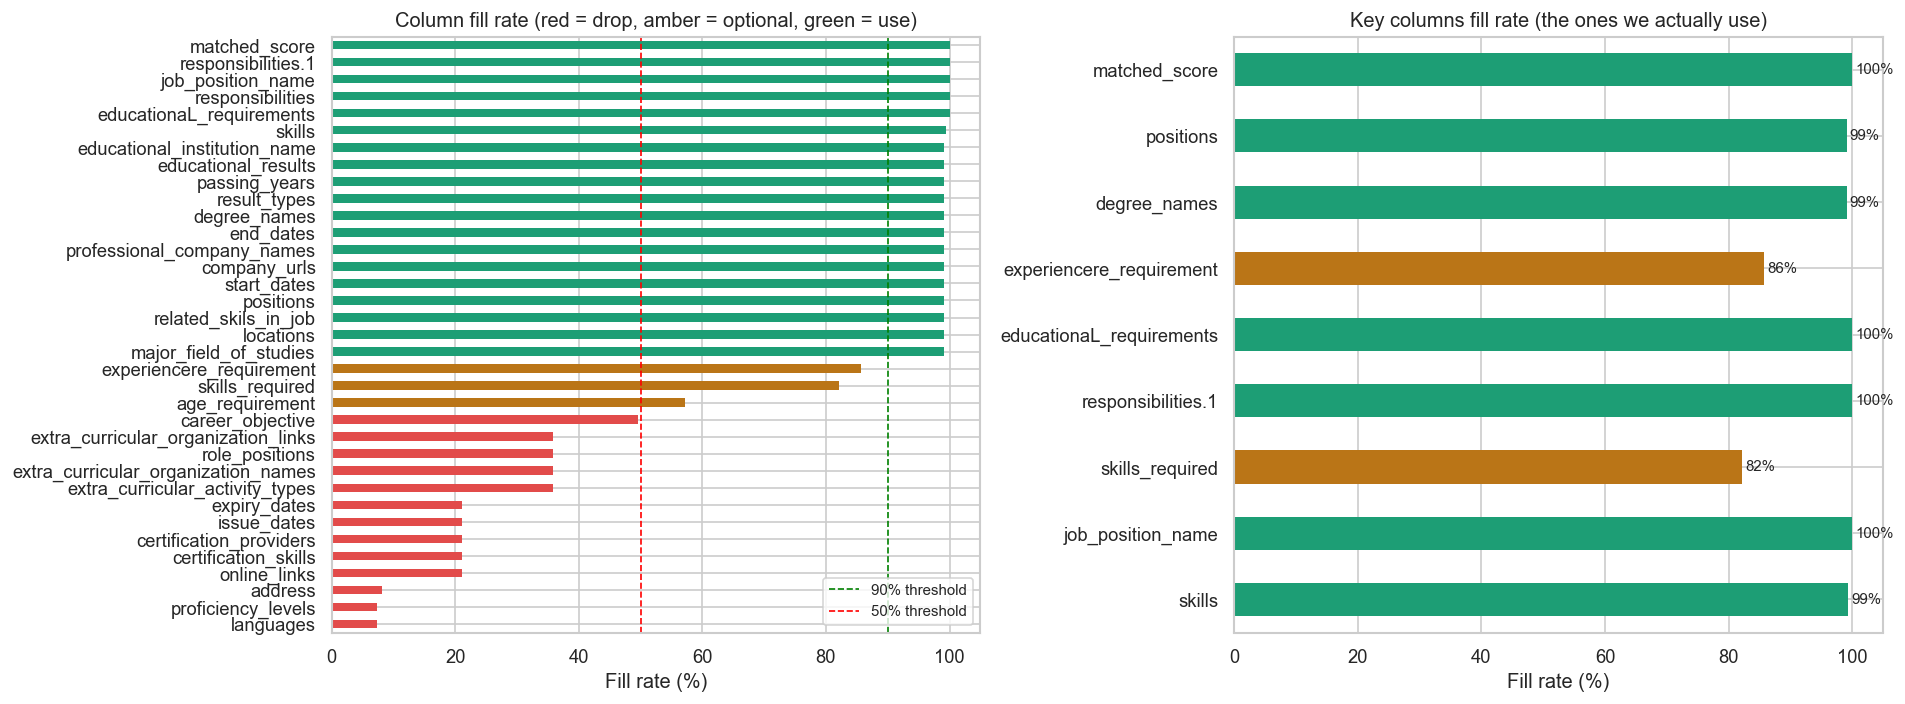

Saved: outputs/plots/01_null_analysis.png


In [6]:
# ── Missing value visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: fill % bar chart
fill_pct = (df_raw.notna().sum() / len(df_raw) * 100).sort_values()
colors = ['#E24B4A' if v < 50 else '#BA7517' if v < 90 else '#1D9E75' for v in fill_pct]
fill_pct.plot(kind='barh', ax=axes[0], color=colors, edgecolor='none')
axes[0].set_xlabel('Fill rate (%)')
axes[0].set_title('Column fill rate (red = drop, amber = optional, green = use)')
axes[0].axvline(90, color='green', linestyle='--', linewidth=1, label='90% threshold')
axes[0].axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
axes[0].legend(fontsize=9)

# Right: just the key columns we'll actually use
key_cols = ['skills', 'job_position_name', 'skills_required',
            'responsibilities.1', 'educationaL_requirements',
            'experiencere_requirement', 'degree_names',
            'positions', 'matched_score']
key_fill = (df_raw[key_cols].notna().sum() / len(df_raw) * 100)
key_colors = ['#1D9E75' if v >= 90 else '#BA7517' if v >= 80 else '#E24B4A'
              for v in key_fill]
key_fill.plot(kind='barh', ax=axes[1], color=key_colors, edgecolor='none')
axes[1].set_xlabel('Fill rate (%)')
axes[1].set_title('Key columns fill rate (the ones we actually use)')
for i, v in enumerate(key_fill):
    axes[1].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/plots/01_null_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/plots/01_null_analysis.png")

## Cell 6 — Target variable (matched_score) EDA

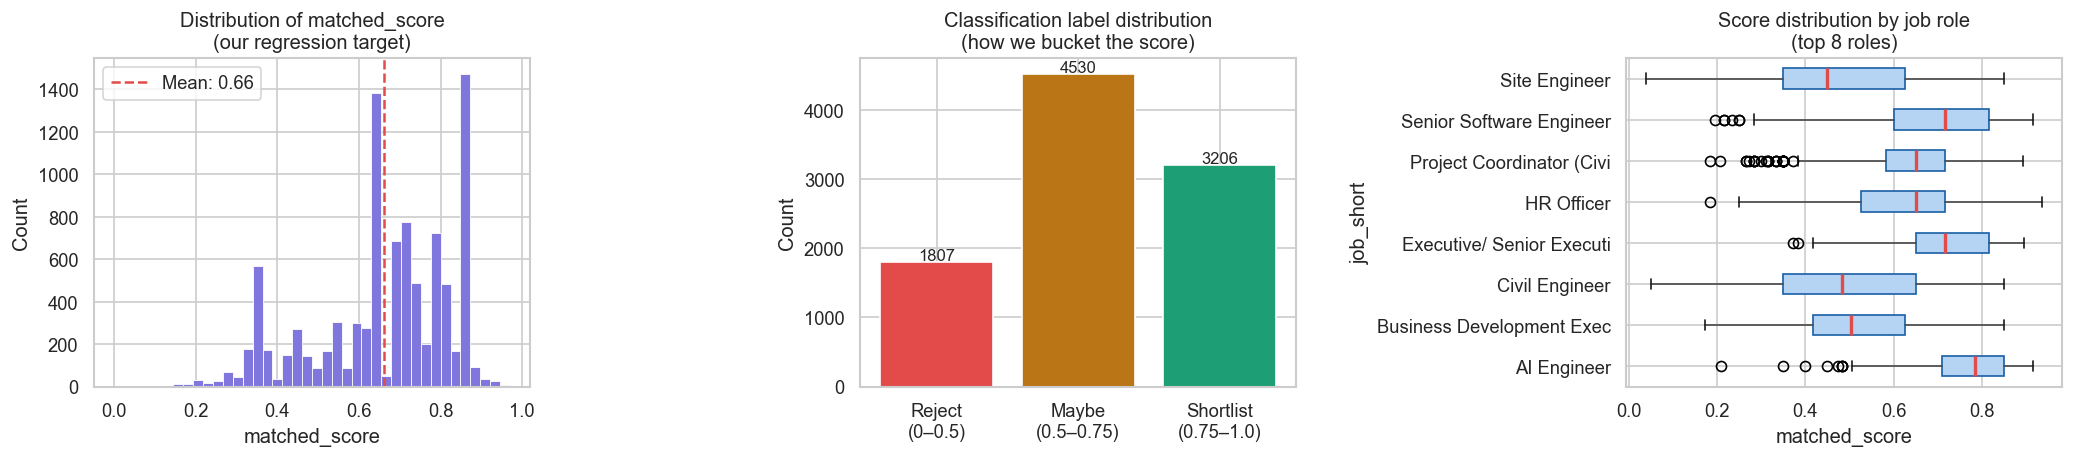


📊 matched_score statistics:
count    9544.000
mean        0.661
std         0.167
min         0.000
25%         0.583
50%         0.683
75%         0.793
max         0.970

Unique score values: 345
Saved: outputs/plots/02_score_distribution.png


In [22]:
# ── matched_score deep dive ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution
axes[0].hist(df_raw['matched_score'].dropna(), bins=40,
             color='#7F77DD', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('matched_score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of matched_score\n(our regression target)')
mean_val = df_raw['matched_score'].mean()
axes[0].axvline(mean_val, color='#E24B4A', linestyle='--',
                linewidth=1.5, label=f'Mean: {mean_val:.2f}')
axes[0].legend()

# 2. Classification buckets
bins   = [0, 0.5, 0.75, 1.01]
labels = ['Reject\n(0–0.5)', 'Maybe\n(0.5–0.75)', 'Shortlist\n(0.75–1.0)']

bucket_counts = pd.cut(df_raw['matched_score'], bins=bins, labels=labels).value_counts()
bucket_counts = bucket_counts.reindex(['Reject\n(0–0.5)', 'Maybe\n(0.5–0.75)', 'Shortlist\n(0.75–1.0)'])

colors_cls = ['#E24B4A', '#BA7517', '#1D9E75']
axes[1].bar(bucket_counts.index, bucket_counts.values,
            color=colors_cls, edgecolor='white')
axes[1].set_title('Classification label distribution\n(how we bucket the score)')
axes[1].set_ylabel('Count')
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=10)

# 3. Box plot by job role (top 8 roles)
top_jobs = df_raw['job_position_name'].value_counts().head(8).index
df_top = df_raw[df_raw['job_position_name'].isin(top_jobs)]
# Wrap long job names
df_top = df_top.copy()
df_top['job_short'] = df_top['job_position_name'].str[:25]
df_top.boxplot(column='matched_score', by='job_short', ax=axes[2],
               vert=False, patch_artist=True,
               boxprops=dict(facecolor='#B5D4F4', color='#185FA5'),
               medianprops=dict(color='#E24B4A', linewidth=2))
axes[2].set_title('Score distribution by job role\n(top 8 roles)')
axes[2].set_xlabel('matched_score')
plt.suptitle('')

plt.tight_layout(pad=3)
plt.savefig('outputs/plots/02_score_distribution.png', bbox_inches='tight')
plt.show()

print("\n📊 matched_score statistics:")
print(df_raw['matched_score'].describe().round(3).to_string())
print(f"\nUnique score values: {df_raw['matched_score'].nunique()}")
print("Saved: outputs/plots/02_score_distribution.png")

## Cell 7 — Job role & skill EDA

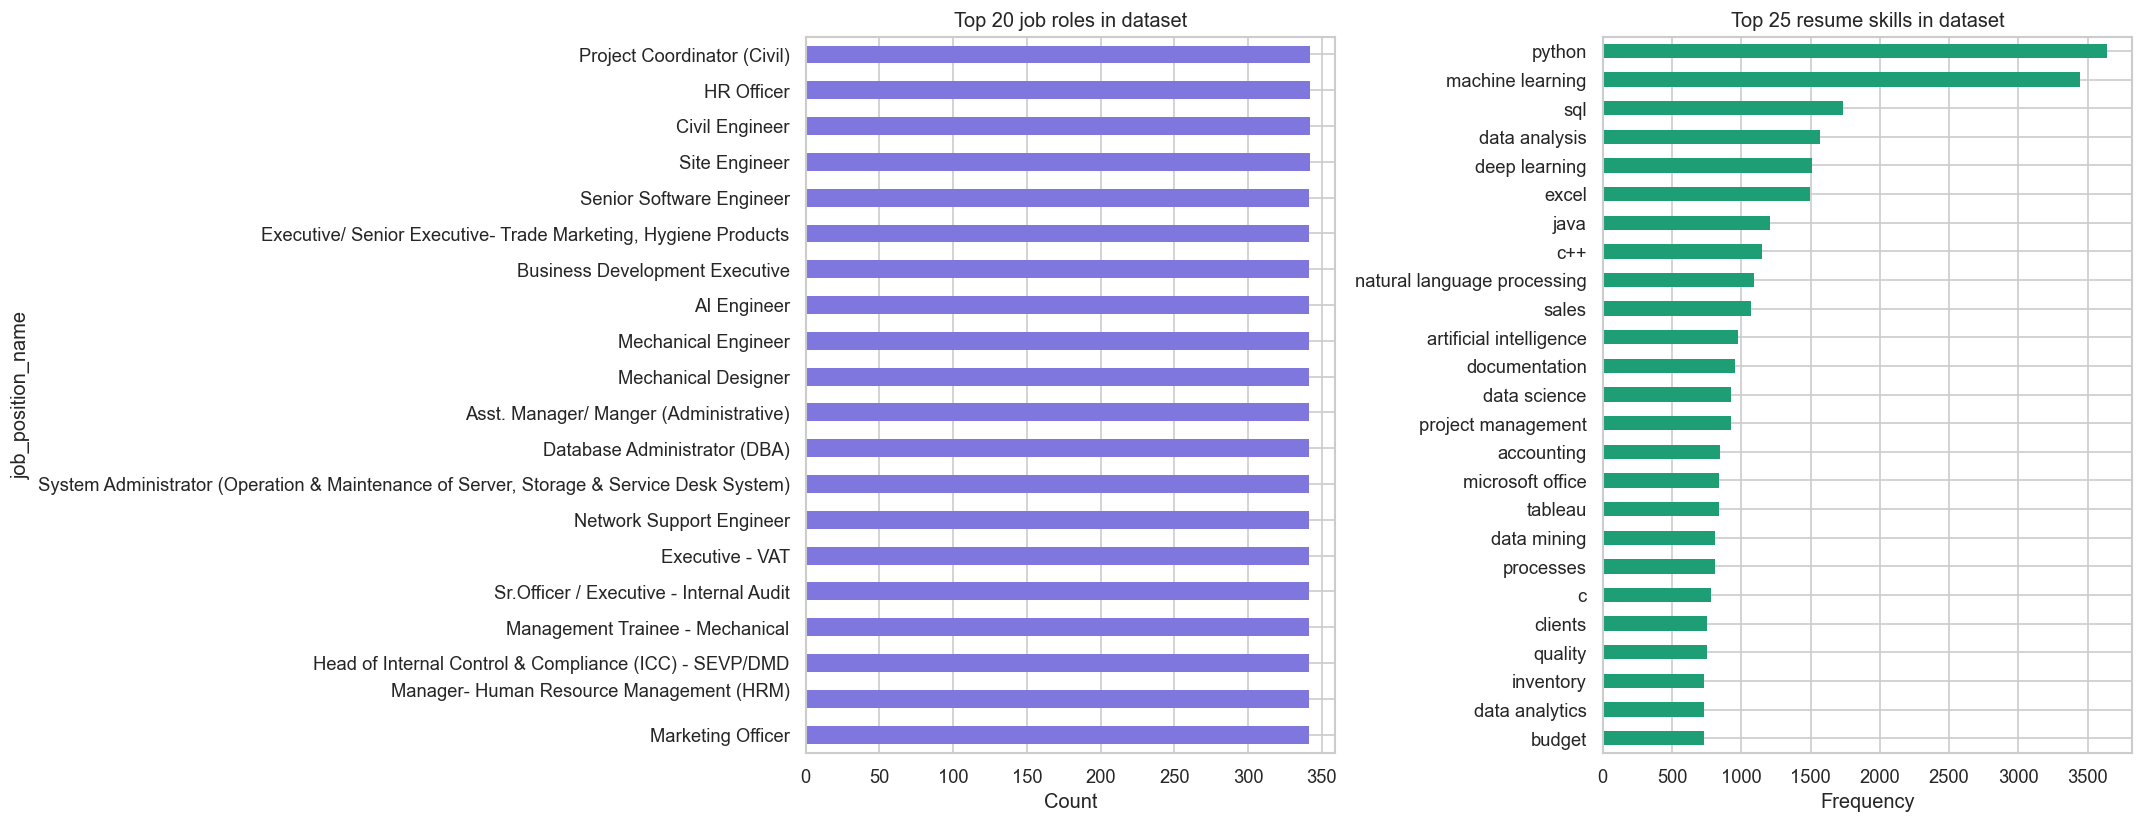

Total unique resume skills found: 2,797
Saved: outputs/plots/03_job_skill_distribution.png


In [8]:
# ── Job role distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top job roles
job_counts = df_raw['job_position_name'].value_counts().head(20)
job_counts.plot(kind='barh', ax=axes[0], color='#7F77DD', edgecolor='none')
axes[0].set_title('Top 20 job roles in dataset')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# Parse skills from string-list format and find top resume skills
def parse_skill_list(s):
    """Parse a string like ['Python', 'SQL'] into a real Python list."""
    if pd.isna(s):
        return []
    try:
        result = ast.literal_eval(str(s))
        if isinstance(result, list):
            return [str(x).strip().lower() for x in result if x]
        return [str(result).strip().lower()]
    except:
        # fallback: split by comma
        return [x.strip().lower() for x in str(s).split(',') if x.strip()]

all_resume_skills = []
for s in df_raw['skills'].dropna():
    all_resume_skills.extend(parse_skill_list(s))

top_skills = pd.Series(Counter(all_resume_skills)).sort_values(ascending=False).head(25)
top_skills.plot(kind='barh', ax=axes[1], color='#1D9E75', edgecolor='none')
axes[1].set_title('Top 25 resume skills in dataset')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/plots/03_job_skill_distribution.png', bbox_inches='tight')
plt.show()
print(f"Total unique resume skills found: {len(set(all_resume_skills)):,}")
print("Saved: outputs/plots/03_job_skill_distribution.png")

## Cell 8 — Skill wordclouds (resume vs JD)

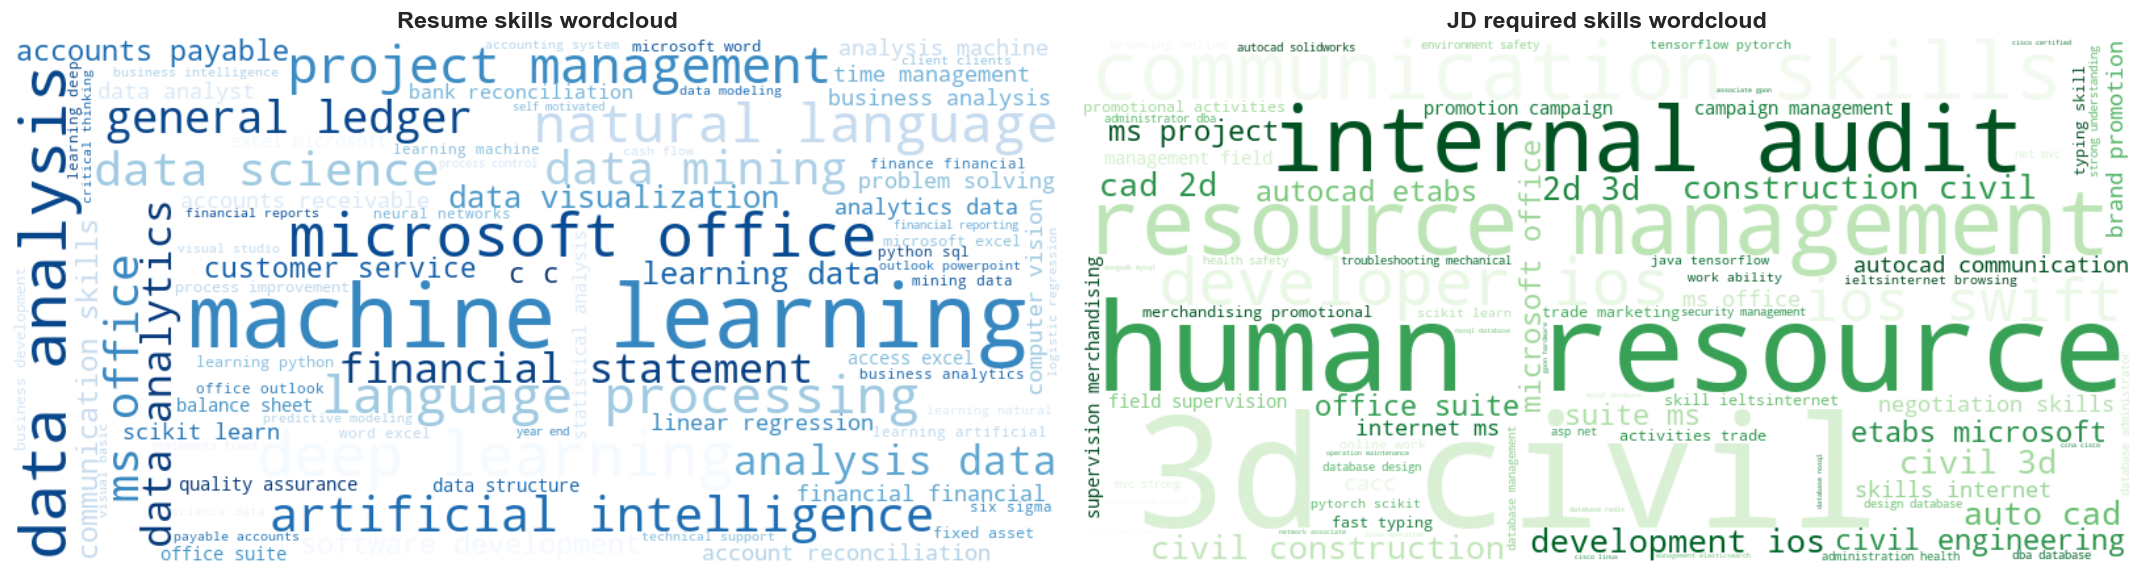

Total unique JD skills found: 97
Saved: outputs/plots/04_wordclouds.png


In [9]:
# ── Wordclouds for resume skills vs required skills ────────────────────────
def parse_jd_skills(s):
    """Parse newline-separated JD skills into a list."""
    if pd.isna(s):
        return []
    return [x.strip().lower() for x in str(s).split('\n') if x.strip()]

all_jd_skills = []
for s in df_raw['skills_required'].dropna():
    all_jd_skills.extend(parse_jd_skills(s))

resume_text = ' '.join(all_resume_skills)
jd_text     = ' '.join(all_jd_skills)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc_resume = WordCloud(width=800, height=400, background_color='white',
                      colormap='Blues', max_words=80).generate(resume_text)
axes[0].imshow(wc_resume, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Resume skills wordcloud', fontsize=14, fontweight='bold')

wc_jd = WordCloud(width=800, height=400, background_color='white',
                  colormap='Greens', max_words=80).generate(jd_text)
axes[1].imshow(wc_jd, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('JD required skills wordcloud', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/plots/04_wordclouds.png', bbox_inches='tight')
plt.show()
print(f"Total unique JD skills found: {len(set(all_jd_skills)):,}")
print("Saved: outputs/plots/04_wordclouds.png")

## Cell 9 — Skill overlap analysis (EDA)

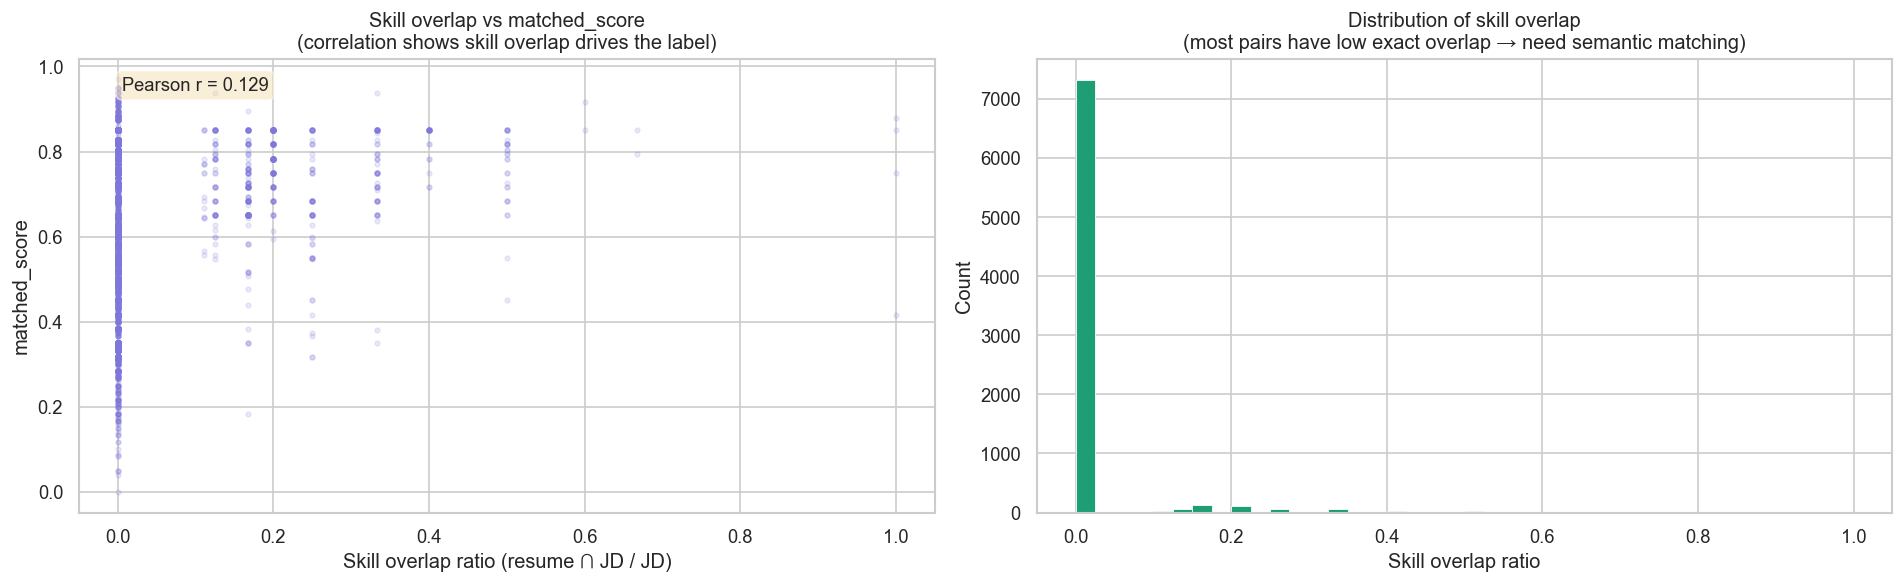

Mean skill overlap: 0.015
Correlation (overlap vs score): 0.129

⚠ Low mean overlap proves WHY semantic matching (SBERT) is needed — exact overlap alone is insufficient.
Saved: outputs/plots/05_skill_overlap_eda.png


In [10]:
# ── How much do resume skills overlap with JD skills per row? ──────────────
# This gives us intuition for what drives matched_score

df_temp = df_raw.dropna(subset=['skills', 'skills_required']).copy()

def skill_overlap_ratio(resume_skills_str, jd_skills_str):
    """What fraction of required JD skills appear in the resume?"""
    resume = set(parse_skill_list(resume_skills_str))
    jd     = set(parse_jd_skills(jd_skills_str))
    if not jd:
        return np.nan
    overlap = resume & jd
    return len(overlap) / len(jd)

df_temp['skill_overlap'] = df_temp.apply(
    lambda r: skill_overlap_ratio(r['skills'], r['skills_required']), axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: skill_overlap vs matched_score
axes[0].scatter(df_temp['skill_overlap'], df_temp['matched_score'],
                alpha=0.15, s=8, color='#7F77DD')
axes[0].set_xlabel('Skill overlap ratio (resume ∩ JD / JD)')
axes[0].set_ylabel('matched_score')
axes[0].set_title('Skill overlap vs matched_score\n(correlation shows skill overlap drives the label)')
corr = df_temp[['skill_overlap','matched_score']].corr().iloc[0,1]
axes[0].text(0.05, 0.93, f'Pearson r = {corr:.3f}',
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Distribution of skill overlap
axes[1].hist(df_temp['skill_overlap'].dropna(), bins=40,
             color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Skill overlap ratio')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of skill overlap\n(most pairs have low exact overlap → need semantic matching)')

plt.tight_layout()
plt.savefig('outputs/plots/05_skill_overlap_eda.png', bbox_inches='tight')
plt.show()
print(f"Mean skill overlap: {df_temp['skill_overlap'].mean():.3f}")
print(f"Correlation (overlap vs score): {corr:.3f}")
print("\n⚠ Low mean overlap proves WHY semantic matching (SBERT) is needed — exact overlap alone is insufficient.")
print("Saved: outputs/plots/05_skill_overlap_eda.png")

## Cell 10 — Correlation matrix of key features (EDA)

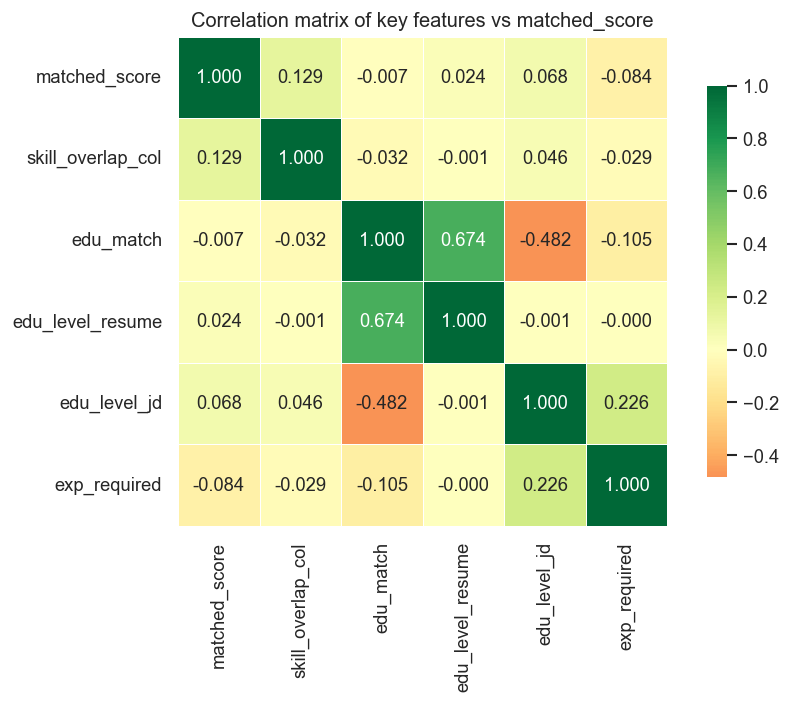

Saved: outputs/plots/06_correlation_matrix.png


In [11]:
# ── Education level encoding (for correlation analysis) ────────────────────
EDU_RANK = {
    'phd': 5, 'doctorate': 5, 'ph.d': 5,
    'm.tech': 4, 'm.sc': 4, 'msc': 4, 'mba': 4, 'master': 4, 'm.e': 4,
    'b.tech': 3, 'b.sc': 3, 'bsc': 3, 'b.e': 3, 'bachelor': 3, 'be': 3,
    'diploma': 2, 'hsc': 1, 'ssc': 1
}

def encode_education(s):
    if pd.isna(s):
        return 2  # default: diploma-level
    s_lower = str(s).lower()
    for key, val in EDU_RANK.items():
        if key in s_lower:
            return val
    return 2

def extract_exp_years(s):
    """Extract numeric years from strings like 'At least 3 year(s)'"""
    if pd.isna(s):
        return 0
    nums = re.findall(r'\d+', str(s))
    return int(nums[0]) if nums else 0

df_corr = df_raw.copy()
df_corr['edu_level_resume'] = df_corr['degree_names'].apply(encode_education)
df_corr['edu_level_jd']     = df_corr['educationaL_requirements'].apply(encode_education)
df_corr['edu_match']        = (df_corr['edu_level_resume'] >= df_corr['edu_level_jd']).astype(int)
df_corr['exp_required']     = df_corr['experiencere_requirement'].apply(extract_exp_years)
df_corr['skill_overlap_col'] = df_temp.set_index(df_temp.index)['skill_overlap'] \
                                if 'skill_overlap' in df_temp.columns else np.nan

corr_cols = ['matched_score', 'skill_overlap_col', 'edu_match',
             'edu_level_resume', 'edu_level_jd', 'exp_required']
corr_matrix = df_corr[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix of key features vs matched_score')
plt.tight_layout()
plt.savefig('outputs/plots/06_correlation_matrix.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/plots/06_correlation_matrix.png")

---
# 🔧 Preprocessing begins here

Everything above was EDA (read-only). From here we build the clean dataset.

## Cell 11 — Step 1–4: Clean & parse core columns

In [12]:
# ── PREPROCESSING PIPELINE ─────────────────────────────────────────────────
# We build df_clean step by step, printing counts at each stage.

print(f"Starting rows: {len(df_raw):,}")

# ── Step 1: Start with a clean copy & rename columns ───────────────────────
df = df_raw.copy()
df.columns = [c.lstrip('\ufeff').strip() for c in df.columns]

# ── Step 2: Drop rows with no skills on either side ────────────────────────
df = df.dropna(subset=['skills', 'skills_required'])
print(f"After dropping rows with null skills or skills_required: {len(df):,}")

# ── Step 3: Parse resume skills (stored as string-list "['Python', 'SQL']") ─
def parse_skill_list(s):
    if pd.isna(s): return []
    try:
        result = ast.literal_eval(str(s))
        if isinstance(result, list):
            return [str(x).strip().lower() for x in result if x and str(x) != 'None']
        return [str(result).strip().lower()]
    except:
        return [x.strip().lower() for x in str(s).split(',') if x.strip()]

# ── Step 4: Parse JD skills (stored as newline-separated text) ─────────────
def parse_jd_skills(s):
    if pd.isna(s): return []
    return [x.strip().lower() for x in str(s).split('\n') if x.strip()]

df['resume_skills'] = df['skills'].apply(parse_skill_list)
df['jd_skills']     = df['skills_required'].apply(parse_jd_skills)

# Drop rows where parsing yielded empty lists
df = df[df['resume_skills'].map(len) > 0]
df = df[df['jd_skills'].map(len) > 0]
print(f"After dropping rows with empty parsed skill lists: {len(df):,}")

# ── Step 5: Clean text columns ─────────────────────────────────────────────
def clean_text(s):
    if pd.isna(s): return ''
    s = str(s).strip()
    s = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', s)  # remove control chars
    s = re.sub(r'\s+', ' ', s)  # normalise whitespace
    return s

df['career_objective_clean']  = df['career_objective'].apply(clean_text)
df['responsibilities_clean']  = df['responsibilities'].apply(clean_text)
df['jd_responsibilities']     = df['responsibilities.1'].apply(clean_text)
df['jd_title']                = df['job_position_name'].apply(clean_text)
df['jd_education_req']        = df['educationaL_requirements'].apply(clean_text)
df['jd_experience_req']       = df['experiencere_requirement'].apply(clean_text)

print(f"\n✅ Step 1–5 complete. Clean rows: {len(df):,}")
print(f"resume_skills — avg skills per resume: {df['resume_skills'].map(len).mean():.1f}")
print(f"jd_skills     — avg skills per JD:     {df['jd_skills'].map(len).mean():.1f}")

Starting rows: 9,544
After dropping rows with null skills or skills_required: 7,797
After dropping rows with empty parsed skill lists: 7,751

✅ Step 1–5 complete. Clean rows: 7,751
resume_skills — avg skills per resume: 21.9
jd_skills     — avg skills per JD:     4.4


## Cell 12 — Step 5: Feature engineering

In [13]:
# ── FEATURE ENGINEERING ────────────────────────────────────────────────────
# Build the feature vector that will be used for:
#   - Training the ML model (regression + classification)
#   - SHAP explainability
#   - Gap analysis display

# ── Feature 1: Exact skill overlap ratio ───────────────────────────────────
# What fraction of JD-required skills appear verbatim in resume?
def exact_overlap_ratio(resume_skills, jd_skills):
    if not jd_skills: return 0.0
    overlap = set(resume_skills) & set(jd_skills)
    return len(overlap) / len(jd_skills)

df['feat_skill_overlap'] = df.apply(
    lambda r: exact_overlap_ratio(r['resume_skills'], r['jd_skills']), axis=1
)

# ── Feature 2: Resume skill count ──────────────────────────────────────────
df['feat_resume_skill_count'] = df['resume_skills'].map(len)

# ── Feature 3: JD skill count ──────────────────────────────────────────────
df['feat_jd_skill_count'] = df['jd_skills'].map(len)

# ── Feature 4: Missing skills count ────────────────────────────────────────
def missing_skills(resume_skills, jd_skills):
    return list(set(jd_skills) - set(resume_skills))

df['missing_skills']          = df.apply(
    lambda r: missing_skills(r['resume_skills'], r['jd_skills']), axis=1
)
df['feat_missing_skill_count'] = df['missing_skills'].map(len)

# ── Feature 5: Education level encoding ────────────────────────────────────
EDU_RANK = {
    'phd': 5, 'ph.d': 5, 'doctorate': 5,
    'm.tech': 4, 'mtech': 4, 'm.sc': 4, 'msc': 4, 'mba': 4, 'master': 4, 'm.e': 4,
    'b.tech': 3, 'btech': 3, 'b.sc': 3, 'bsc': 3, 'b.e': 3, 'bachelor': 3, 'be': 3,
    'diploma': 2, 'hsc': 1, 'ssc': 1
}

def encode_education(s):
    if pd.isna(s): return 2
    s_lower = str(s).lower()
    for key, val in sorted(EDU_RANK.items(), key=lambda x: -x[1]):
        if key in s_lower:
            return val
    return 2

df['feat_edu_level_resume'] = df['degree_names'].apply(encode_education)
df['feat_edu_level_jd']     = df['jd_education_req'].apply(encode_education)
df['feat_edu_match']        = (df['feat_edu_level_resume'] >= df['feat_edu_level_jd']).astype(int)

# ── Feature 6: Experience years required ───────────────────────────────────
def extract_exp_years(s):
    if pd.isna(s): return 0
    nums = re.findall(r'\d+', str(s))
    return int(nums[0]) if nums else 0

df['feat_exp_years_required'] = df['jd_experience_req'].apply(extract_exp_years)

# ── Feature 7: Resume text length (proxy for detail) ───────────────────────
df['feat_resume_text_len'] = (df['career_objective_clean'] + ' ' +
                               df['responsibilities_clean']).str.len()

# ── Summary ────────────────────────────────────────────────────────────────
FEATURE_COLS = [
    'feat_skill_overlap',
    'feat_resume_skill_count',
    'feat_jd_skill_count',
    'feat_missing_skill_count',
    'feat_edu_match',
    'feat_edu_level_resume',
    'feat_edu_level_jd',
    'feat_exp_years_required',
    'feat_resume_text_len',
]

print("✅ Feature engineering complete.")
print(f"   Feature columns: {FEATURE_COLS}")
print()
df[FEATURE_COLS + ['matched_score']].describe().round(3)

✅ Feature engineering complete.
   Feature columns: ['feat_skill_overlap', 'feat_resume_skill_count', 'feat_jd_skill_count', 'feat_missing_skill_count', 'feat_edu_match', 'feat_edu_level_resume', 'feat_edu_level_jd', 'feat_exp_years_required', 'feat_resume_text_len']



,feat_skill_overlap,feat_resume_skill_count,feat_jd_skill_count,feat_missing_skill_count,feat_edu_match,feat_edu_level_resume,feat_edu_level_jd,feat_exp_years_required,feat_resume_text_len,matched_score
count,7751.000,7751.000,7751.000,7751.000,7751.000,7751.000,7751.000,7751.000,7751.000,7751.000
mean,0.015,21.890,4.389,4.319,0.651,3.048,3.218,3.174,325.895,0.647
std,0.066,19.243,2.372,2.360,0.477,0.720,0.507,3.088,183.235,0.169
min,0.000,3.000,1.000,0.000,0.000,2.000,2.000,0.000,73.000,0.000
25%,0.000,10.000,2.000,2.000,0.000,3.000,3.000,1.000,192.000,0.550
50%,0.000,14.000,4.000,4.000,1.000,3.000,3.000,3.000,285.000,0.683
75%,0.000,29.000,6.000,6.000,1.000,4.000,4.000,5.000,421.000,0.783
max,1.000,144.000,9.000,9.000,1.000,5.000,4.000,15.000,2013.000,0.970


## Cell 13 — Step 6: Classification labels + SBERT similarity

In [14]:
# ── Classification label ───────────────────────────────────────────────────
def make_label(score):
    if score < 0.5:  return 'Reject'
    if score < 0.75: return 'Maybe'
    return 'Shortlist'

df['label'] = df['matched_score'].apply(make_label)

label_counts = df['label'].value_counts()
print("Classification label distribution:")
print(label_counts.to_string())
print()

# ── SBERT semantic similarity (this is Agent 3 core logic) ────────────────
# NOTE: This takes ~5–10 min on CPU for 7,843 rows.
# On Colab GPU: Runtime → Change runtime type → T4 GPU (free) → much faster.
# If you want to skip during development, set COMPUTE_SBERT = False

COMPUTE_SBERT = True   # ← set False to skip during quick testing

if COMPUTE_SBERT:
    from sentence_transformers import SentenceTransformer, util

    print("Loading SBERT model (all-MiniLM-L6-v2)...")
    sbert = SentenceTransformer('all-MiniLM-L6-v2')

    # Build text representations for embedding
    # Resume: join skills into a sentence
    # JD: join required skills into a sentence
    resume_texts = df['resume_skills'].apply(lambda s: ', '.join(s)).tolist()
    jd_texts     = df['jd_skills'].apply(lambda s: ', '.join(s)).tolist()

    print("Encoding resumes...")
    resume_embs = sbert.encode(resume_texts, batch_size=64,
                                show_progress_bar=True, convert_to_tensor=True)
    print("Encoding JDs...")
    jd_embs = sbert.encode(jd_texts, batch_size=64,
                            show_progress_bar=True, convert_to_tensor=True)

    # Cosine similarity per pair
    sbert_scores = util.cos_sim(resume_embs, jd_embs).diagonal().cpu().numpy()
    df['feat_sbert_similarity'] = sbert_scores
    FEATURE_COLS.append('feat_sbert_similarity')

    print(f"\n✅ SBERT similarity computed. Mean: {sbert_scores.mean():.3f}")
    corr_sbert = df[['feat_sbert_similarity','matched_score']].corr().iloc[0,1]
    print(f"   Correlation with matched_score: {corr_sbert:.3f}")
else:
    df['feat_sbert_similarity'] = np.nan
    print("⚠ SBERT skipped (COMPUTE_SBERT=False). Set True for full features.")

Classification label distribution:
label
Maybe        3438
Shortlist    2699
Reject       1614



d:\PES\sem 6\genai\genai-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SBERT model (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 374.86it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding resumes...


Batches: 100%|██████████| 122/122 [04:03<00:00,  2.00s/it]


Encoding JDs...


Batches: 100%|██████████| 122/122 [00:27<00:00,  4.48it/s]



✅ SBERT similarity computed. Mean: 0.258
   Correlation with matched_score: 0.162


## Cell 14 — Feature distribution plots

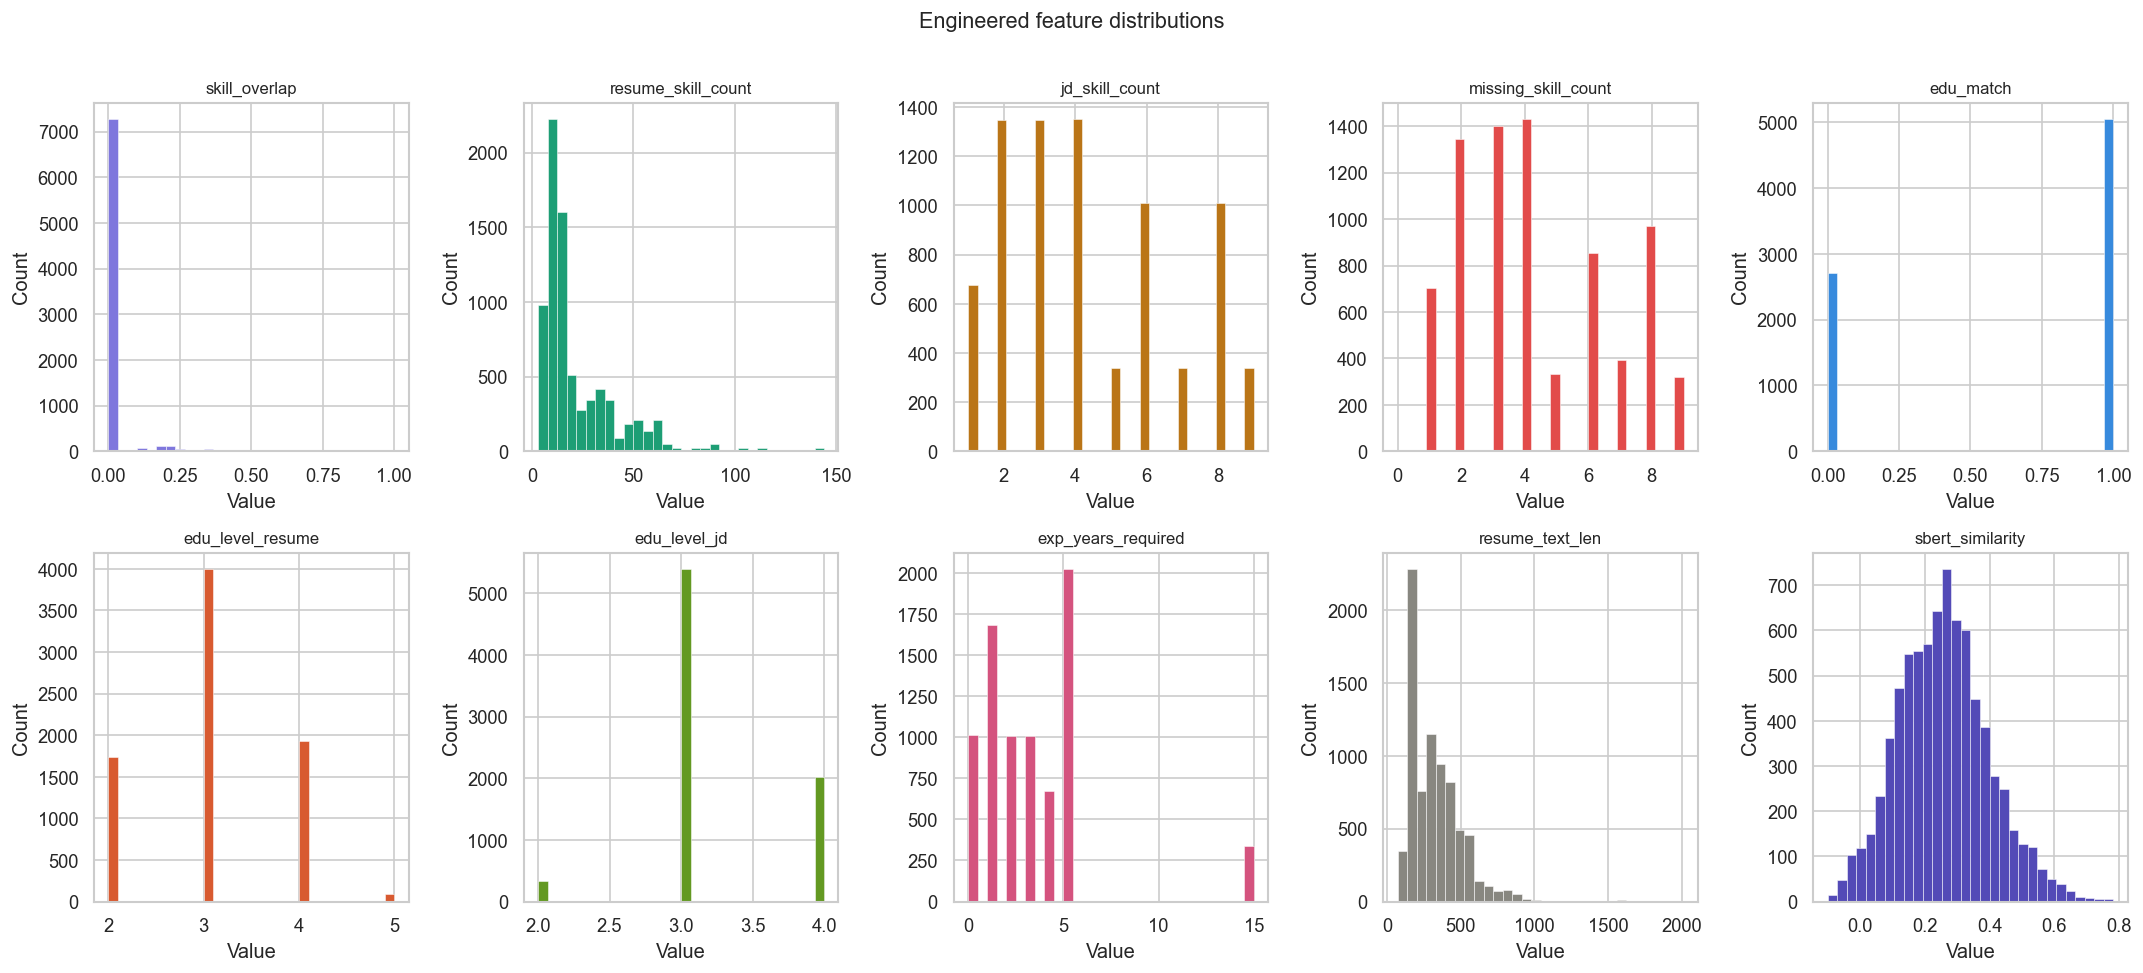

Saved: outputs/plots/07_feature_distributions.png


In [15]:
# ── Plot all engineered features ───────────────────────────────────────────
plot_feats = [f for f in FEATURE_COLS if df[f].notna().sum() > 100]
n = len(plot_feats)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(18, 8))
axes = axes.flatten()

palette = ['#7F77DD', '#1D9E75', '#BA7517', '#E24B4A',
           '#378ADD', '#D85A30', '#639922', '#D4537E', '#888780', '#534AB7']

for i, feat in enumerate(plot_feats):
    axes[i].hist(df[feat].dropna(), bins=30,
                 color=palette[i % len(palette)], edgecolor='white', linewidth=0.3)
    axes[i].set_title(feat.replace('feat_', ''), fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Engineered feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/plots/07_feature_distributions.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/plots/07_feature_distributions.png")

## Cell 15 — Build RAG corpus (3,343 unique skills → FAISS index)

In [16]:
# ── BUILD RAG KNOWLEDGE BASE ───────────────────────────────────────────────
# This is Agent 2's core: a FAISS vector store of all unique skills.
# At inference time: user's raw skill text → embed → find nearest canonical skill.

import faiss
from sentence_transformers import SentenceTransformer

# Collect all unique skills from both sides
all_skills_set = set()
for s in df['resume_skills']:
    all_skills_set.update(s)
for s in df['jd_skills']:
    all_skills_set.update(s)

# Remove very short noise tokens
skill_corpus = sorted([s for s in all_skills_set if len(s) > 2])
print(f"Total unique skills in RAG corpus: {len(skill_corpus):,}")
print(f"Sample skills: {skill_corpus[:10]}")

# Save the skill corpus as a plain list (for lookup after FAISS search)
with open('outputs/skill_corpus.json', 'w') as f:
    json.dump(skill_corpus, f, indent=2)
print("Saved: outputs/skill_corpus.json")

# Embed all skills with SBERT
if 'sbert' not in dir():
    sbert = SentenceTransformer('all-MiniLM-L6-v2')

print("\nEmbedding skill corpus for FAISS...")
skill_embeddings = sbert.encode(skill_corpus, batch_size=128,
                                 show_progress_bar=True,
                                 normalize_embeddings=True)  # L2-normalize for cosine sim

# Build FAISS index (IndexFlatIP = inner product = cosine sim for normalized vectors)
dim = skill_embeddings.shape[1]   # 384 for MiniLM
index = faiss.IndexFlatIP(dim)
index.add(skill_embeddings.astype('float32'))

print(f"\nFAISS index built. Vectors stored: {index.ntotal:,} | Dimension: {dim}")

# Save FAISS index
faiss.write_index(index, 'outputs/skill_faiss.index')
print("Saved: outputs/skill_faiss.index")

# Quick sanity check — query 'machine learning' → should find similar skills
query = 'machine learning'
q_emb = sbert.encode([query], normalize_embeddings=True).astype('float32')
scores, indices = index.search(q_emb, 5)
print(f"\n🔍 RAG test — query: '{query}'")
for score, idx in zip(scores[0], indices[0]):
    print(f"   → {skill_corpus[idx]:<35} (similarity: {score:.3f})")

Total unique skills in RAG corpus: 2,831
Sample skills: ['.net', '.ney(vb, asp)', '10key by touch', '15+ years of experience in accounting & bookkeeping services', '2-tier', '2000', '3d modeling', '3d printing', '3ds max', '3dsmax']
Saved: outputs/skill_corpus.json

Embedding skill corpus for FAISS...


Batches: 100%|██████████| 23/23 [00:09<00:00,  2.51it/s]


FAISS index built. Vectors stored: 2,831 | Dimension: 384
Saved: outputs/skill_faiss.index

🔍 RAG test — query: 'machine learning'
   → machine learning                    (similarity: 1.000)
   → applied machine learning            (similarity: 0.780)
   → machine learning engineering        (similarity: 0.756)
   → learning algorithm                  (similarity: 0.732)
   → data mining                         (similarity: 0.720)


## Cell 16 — Compile final clean dataset

In [17]:
# ── FINAL CLEAN DATASET ────────────────────────────────────────────────────
# Select only the columns needed downstream (model training + agents)

KEEP_COLS = [
    # Identifiers
    'jd_title',

    # Resume text (for Agent 1/5 LLM prompts)
    'career_objective_clean',
    'responsibilities_clean',
    'resume_skills',          # parsed list
    'degree_names',
    'positions',

    # JD text (for Agent 1/5 LLM prompts)
    'jd_responsibilities',
    'jd_skills',              # parsed list
    'jd_education_req',
    'jd_experience_req',

    # Agent 4: gap analysis
    'missing_skills',

    # ML features (Agent 3: matching model)
    *FEATURE_COLS,

    # Labels
    'matched_score',          # regression target
    'label',                  # classification target
]

df_clean = df[KEEP_COLS].reset_index(drop=True)

print(f"Final clean dataset shape: {df_clean.shape}")
print(f"\nColumn dtypes:")
print(df_clean.dtypes.to_string())
print(f"\nNull counts in final dataset:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].to_string())

Final clean dataset shape: (7751, 23)

Column dtypes:
jd_title                        str
career_objective_clean          str
responsibilities_clean          str
resume_skills                object
degree_names                    str
positions                       str
jd_responsibilities             str
jd_skills                    object
jd_education_req                str
jd_experience_req               str
missing_skills               object
feat_skill_overlap          float64
feat_resume_skill_count       int64
feat_jd_skill_count           int64
feat_missing_skill_count      int64
feat_edu_match                int64
feat_edu_level_resume         int64
feat_edu_level_jd             int64
feat_exp_years_required       int64
feat_resume_text_len          int64
feat_sbert_similarity       float32
matched_score               float64
label                           str

Null counts in final dataset:
degree_names    69
positions       69


## Cell 17 — Train / test / validation split

In [18]:
# ── TRAIN / VALIDATION / TEST SPLIT ───────────────────────────────────────
# 70% train | 15% validation | 15% test
# Stratified on 'label' so each split has balanced Reject/Maybe/Shortlist

df_trainval, df_test = train_test_split(
    df_clean,
    test_size=0.15,
    stratify=df_clean['label'],
    random_state=42
)

df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.176,   # 0.176 of 0.85 ≈ 0.15 of total
    stratify=df_trainval['label'],
    random_state=42
)

print(f"Train:      {len(df_train):,} rows ({len(df_train)/len(df_clean)*100:.0f}%)")
print(f"Validation: {len(df_val):,} rows ({len(df_val)/len(df_clean)*100:.0f}%)")
print(f"Test:       {len(df_test):,} rows ({len(df_test)/len(df_clean)*100:.0f}%)")
print()
print("Label distribution across splits:")
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    counts = split['label'].value_counts(normalize=True).round(3) * 100
    print(f"  {name:6}: " + ' | '.join([f"{k}: {v:.0f}%" for k,v in counts.items()]))

# Save splits
df_train.to_csv('outputs/train.csv', index=False)
df_val.to_csv('outputs/val.csv',   index=False)
df_test.to_csv('outputs/test.csv', index=False)
df_clean.to_csv('outputs/full_clean.csv', index=False)

print("\n✅ Splits saved:")
print("   outputs/train.csv")
print("   outputs/val.csv")
print("   outputs/test.csv")
print("   outputs/full_clean.csv")

Train:      5,428 rows (70%)
Validation: 1,160 rows (15%)
Test:       1,163 rows (15%)

Label distribution across splits:
  Train : Maybe: 44% | Shortlist: 35% | Reject: 21%
  Val   : Maybe: 44% | Shortlist: 35% | Reject: 21%
  Test  : Maybe: 44% | Shortlist: 35% | Reject: 21%

✅ Splits saved:
   outputs/train.csv
   outputs/val.csv
   outputs/test.csv
   outputs/full_clean.csv


## Cell 18 — Save metadata & feature config

In [19]:
# ── SAVE CONFIG for downstream notebooks ──────────────────────────────────
# This JSON file tells the model training notebook which columns to use
# so there's no hardcoding across files.

config = {
    'feature_cols': FEATURE_COLS,
    'regression_target': 'matched_score',
    'classification_target': 'label',
    'class_labels': ['Reject', 'Maybe', 'Shortlist'],
    'edu_rank_map': EDU_RANK,
    'split_random_state': 42,
    'train_size': len(df_train),
    'val_size': len(df_val),
    'test_size': len(df_test),
    'total_clean_rows': len(df_clean),
    'unique_jobs': int(df_clean['jd_title'].nunique()),
    'unique_skills_in_rag': len(skill_corpus),
    'sbert_model': 'all-MiniLM-L6-v2',
    'faiss_index_path': 'outputs/skill_faiss.index',
    'skill_corpus_path': 'outputs/skill_corpus.json',
}

with open('outputs/preprocessing_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✅ Config saved: outputs/preprocessing_config.json")
print()
print(json.dumps(config, indent=2))

✅ Config saved: outputs/preprocessing_config.json

{
  "feature_cols": [
    "feat_skill_overlap",
    "feat_resume_skill_count",
    "feat_jd_skill_count",
    "feat_missing_skill_count",
    "feat_edu_match",
    "feat_edu_level_resume",
    "feat_edu_level_jd",
    "feat_exp_years_required",
    "feat_resume_text_len",
    "feat_sbert_similarity"
  ],
  "regression_target": "matched_score",
  "classification_target": "label",
  "class_labels": [
    "Reject",
    "Maybe",
    "Shortlist"
  ],
  "edu_rank_map": {
    "phd": 5,
    "ph.d": 5,
    "doctorate": 5,
    "m.tech": 4,
    "mtech": 4,
    "m.sc": 4,
    "msc": 4,
    "mba": 4,
    "master": 4,
    "m.e": 4,
    "b.tech": 3,
    "btech": 3,
    "b.sc": 3,
    "bsc": 3,
    "b.e": 3,
    "bachelor": 3,
    "be": 3,
    "diploma": 2,
    "hsc": 1,
    "ssc": 1
  },
  "split_random_state": 42,
  "train_size": 5428,
  "val_size": 1160,
  "test_size": 1163,
  "total_clean_rows": 7751,
  "unique_jobs": 23,
  "unique_skills_in_rag":

## Cell 19 — Final summary & what each output file is for

In [23]:
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────
import os

print("=" * 60)
print("PREPROCESSING COMPLETE — OUTPUT FILES")
print("=" * 60)

output_files = {
    'outputs/full_clean.csv':              'Full preprocessed dataset (all rows)',
    'outputs/train.csv':                   'Training split (70%) — feed to model notebook',
    'outputs/val.csv':                     'Validation split (15%) — hyperparameter tuning',
    'outputs/test.csv':                    'Test split (15%) — final evaluation only',
    'outputs/skill_corpus.json':           'RAG knowledge base — list of all unique skills',
    'outputs/skill_faiss.index':           'FAISS index — load this for Agent 2 at inference',
    'outputs/preprocessing_config.json':   'Feature names + config — load in every other notebook',
    'outputs/plots/':                      'All EDA plots (include in research paper)',
}

for path, desc in output_files.items():
    if os.path.exists(path):
        if os.path.isdir(path):
            size = sum(os.path.getsize(os.path.join(path,f))
                      for f in os.listdir(path)) / 1024
            print(f"  ✅ {path:<45} {size:.0f} KB   — {desc}")
        else:
            size = os.path.getsize(path) / 1024
            print(f"  ✅ {path:<45} {size:.0f} KB   — {desc}")
    else:
        print(f"  ⚠  {path:<45} NOT FOUND")

print()
# print("NEXT STEPS for your team:")
# print("  1. Commit the entire outputs/ folder to your GitHub repo")
print("  2. Notebook 2 (model_training.ipynb): load train.csv + config → train RF + XGBoost")
print("  3. Notebook 3 (agents.ipynb): load faiss index + model → wire all 5 agents")
print("  4. Notebook 4 (demo.ipynb): Streamlit UI calling the agent pipeline")
print()
# print("✅ This notebook is self-contained. Anyone on the team can run it top-to-bottom.")

PREPROCESSING COMPLETE — OUTPUT FILES
  ✅ outputs/full_clean.csv                        10215 KB   — Full preprocessed dataset (all rows)
  ✅ outputs/train.csv                             7146 KB   — Training split (70%) — feed to model notebook
  ✅ outputs/val.csv                               1520 KB   — Validation split (15%) — hyperparameter tuning
  ✅ outputs/test.csv                              1550 KB   — Test split (15%) — final evaluation only
  ✅ outputs/skill_corpus.json                     69 KB   — RAG knowledge base — list of all unique skills
  ✅ outputs/skill_faiss.index                     4247 KB   — FAISS index — load this for Agent 2 at inference
  ✅ outputs/preprocessing_config.json             1 KB   — Feature names + config — load in every other notebook
  ✅ outputs/plots/                                1327 KB   — All EDA plots (include in research paper)

  2. Notebook 2 (model_training.ipynb): load train.csv + config → train RF + XGBoost
  3. Notebook 3 (agen